# 🔹 Model Testing with Different Seeds

This section generates different seeds and evaluates the model using each of them.


In [2]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import librosa.display
import tensorflow as tf
from IPython.display import Audio

import torchaudio
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import Wav2Vec2Model, Wav2Vec2Processor, Trainer, TrainingArguments, Wav2Vec2ForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import opensmile
from tqdm import tqdm
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models
import warnings
warnings.filterwarnings('ignore')

c:\Users\41788\anaconda3\envs\audio_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 🔹 Dataset Loading
- Load all audio file paths and their corresponding labels from the dataset.
- Each subdirectory represents a different label (dog breed).
- Collect file paths and assign labels based on folder names.
- Store results in a DataFrame for further processing.

In [ ]:
base_dir = r'D:\Scuola\TESI-2025\Mescalina2017_sorted\FrenchPoodle\sounds'

paths = []
labels = []

for dirname, _, filenames in os.walk(base_dir):
    for filename in filenames:
        file_path = os.path.join(dirname, filename)
        paths.append(file_path)
        label = os.path.basename(dirname)
        labels.append(label)
print('Dataset is Loaded')

df = pd.DataFrame({"audio_paths": paths, "labels": labels})
print(df.head())
print(df['labels'].value_counts())
print(f"\nTotale file: {len(df)}, razze: {df['labels'].nunique()}")

Dataset is Loaded
                                         audio_paths labels
0  D:\Scuola\TESI-2025\Mescalina2017_sorted\Frenc...  B-AGR
1  D:\Scuola\TESI-2025\Mescalina2017_sorted\Frenc...  B-AGR
2  D:\Scuola\TESI-2025\Mescalina2017_sorted\Frenc...  B-AGR
3  D:\Scuola\TESI-2025\Mescalina2017_sorted\Frenc...  B-AGR
4  D:\Scuola\TESI-2025\Mescalina2017_sorted\Frenc...  B-AGR
labels
B-NEU     940
B-AGR     620
B-OWN     197
W-NEG      91
G-NEG      87
B-ANX      86
B-PLY      39
G-POS      21
W-POS      18
B-HOM      14
B-FEAR      9
B-WLK       1
Name: count, dtype: int64

Totale file: 2123, razze: 12


# 🔹 Data Filtering
- Count files per label.
- Keep only labels with a minimum number of files (e.g., 80 or 100).
- Subset the DataFrame to ensure balanced representation per label.
- Visualize label distribution.

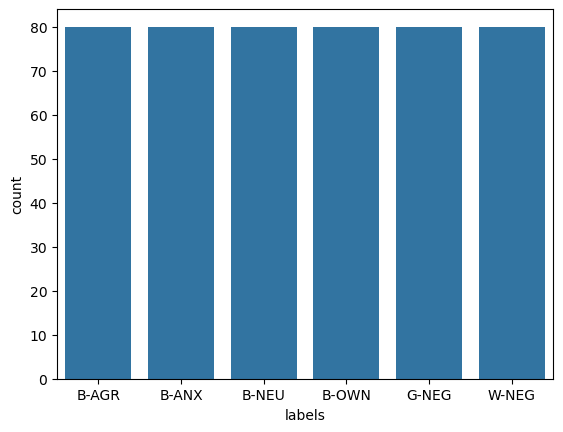

In [ ]:
MIN_FILES = 80

label_counts = df['labels'].value_counts()

valid_labels = label_counts[label_counts >= MIN_FILES].index

filtered_df = df[df['labels'].isin(valid_labels)]

df = filtered_df.groupby('labels').head(MIN_FILES).reset_index(drop=True)

sns.countplot(x='labels', data=df)
plt.show()

label_counts = df['labels'].value_counts()
valid_labels = label_counts[label_counts >= MIN_FILES].index
filtered_df = df[df['labels'].isin(valid_labels)]
df = filtered_df.groupby('labels').head(MIN_FILES).reset_index(drop=True)

# 🔹  Seeded Data Splits
- Create multiple random splits using different seeds.
- Split dataset into training (70%) and validation+test (30%).
- Split the validation+test subset evenly (50%-50%) for validation and test.
- Save train, validation, and test audio paths for each seed.

In [ ]:
seeds = [0, 1, 2, 3, 4]

base_dir = "split_lists/frenchPoodle"
os.makedirs(base_dir, exist_ok=True)

def load_paths(file_path):
        with open(file_path) as f:
            return [line.strip() for line in f]
        
def extract_lld_features(audio_path):
    """Estrae LLD e applica padding se necessario"""
    smile = opensmile.Smile(
        feature_set=opensmile.FeatureSet.ComParE_2016,
        feature_level=opensmile.FeatureLevel.LowLevelDescriptors
    )
    features = smile.process_file(audio_path).values
    return features     

all_models = {}
all_params = {}
all_label_encoders = {}
results = {}   

# 🔹 Multi-Seed Training Pipeline for Dog Breed Audio Classification

## Seeded Data Splits
- Iterate over all seeds (`seeds = [0, 1, 2, 3, 4]`) to create reproducible dataset splits.
- For each seed:
  - Create a seed-specific output directory.
  - Split the dataset into:
    - 70% training
    - 30% validation + test
    - Further split the 30% into 50% validation and 50% test.
  - Save train, validation, and test audio paths as text files.
  - Load splits from the saved files to subset the main DataFrame.
  - Print the number of samples in each split for verification.

## Feature Extraction
- Extract Low-Level Descriptors (LLDs) from all audio files in train, validation, and test sets.
- Determine the maximum sequence length and the number of features.
- Apply padding/truncating to ensure consistent sequence lengths.

## Label Encoding
- Encode string labels into numeric values for training and evaluation.

## Normalization
- Standardize features using the mean and standard deviation computed on the training set.
- Apply the same normalization to validation and test sets.

## Reshape for CNN Input
- Reshape the data to `(samples, max_len, n_features, 1)` to feed into Conv1D layers.

## Model Definition
- Build a 1D CNN with:
  - Conv1D layers with ReLU activation
  - MaxPooling layers
  - GlobalAveragePooling
  - Dense output layer with softmax activation
- Compile using Adam optimizer and sparse categorical crossentropy loss.

## Training and Evaluation
- Train the model for 100 epochs with batch size 32.
- Evaluate test accuracy and loss for each seed.
- Store:
  - Training and validation metrics
  - Test results
  - Trained model
  - Preprocessing parameters (mean, std, max_len, n_features)
  - Label encoder


In [ ]:
for seed in seeds:
    seed_dir = os.path.join(base_dir, f"seed_{seed}")
    os.makedirs(seed_dir, exist_ok=True)

    # Split 70% train, 30% val+test
    train_df, val_test_df = train_test_split(
        df, test_size=0.3, stratify=df['labels'], random_state=seed)

    # Split 15% val, 15% test (dal 30%)
    val_df, test_df = train_test_split(
        val_test_df, test_size=0.5, stratify=val_test_df['labels'], random_state=seed)

    for split_name, split_df in zip(['train', 'val', 'test'], [train_df, val_df, test_df]):
        file_path = os.path.join(seed_dir, f"{split_name}.txt")
        with open(file_path, "w") as f:
            for path in split_df['audio_paths']:
                f.write(f"{path}\n")

    print(f"[✓] Split created for seed {seed}: {seed_dir}/")


    train_paths = load_paths(os.path.join(seed_dir, "train.txt"))
    val_paths = load_paths(os.path.join(seed_dir, "val.txt"))
    test_paths = load_paths(os.path.join(seed_dir, "test.txt"))

    train_df = df[df['audio_paths'].isin(train_paths)].reset_index(drop=True)
    val_df = df[df['audio_paths'].isin(val_paths)].reset_index(drop=True)
    test_df = df[df['audio_paths'].isin(test_paths)].reset_index(drop=True)

    print(f"[✓] Split loaded from seed {seed}")
    print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

    print("Extracting LLD features...")
    train_sequences = [extract_lld_features(path) for path in tqdm(train_df['audio_paths'])]
    val_sequences = [extract_lld_features(path) for path in tqdm(val_df['audio_paths'])]
    test_sequences = [extract_lld_features(path) for path in tqdm(test_df['audio_paths'])]

    max_len = max(seq.shape[0] for seq in train_sequences + val_sequences + test_sequences)
    n_features = train_sequences[0].shape[1]

    X_train = pad_sequences(train_sequences, maxlen=max_len, dtype='float32', padding='post', truncating='post')
    X_val = pad_sequences(val_sequences, maxlen=max_len, dtype='float32', padding='post', truncating='post')
    X_test = pad_sequences(test_sequences, maxlen=max_len, dtype='float32', padding='post', truncating='post')

    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(train_df['labels'])

    y_val = label_encoder.transform(val_df['labels'])
    y_test = label_encoder.transform(test_df['labels'])

    mean = X_train.mean(axis=(0,1)) 
    std = X_train.std(axis=(0,1))   

    X_train = (X_train - mean) / (std + 1e-8)
    X_val = (X_val - mean) / (std + 1e-8)
    X_test = (X_test - mean) / (std + 1e-8)

    X_train = X_train.reshape(-1, max_len, n_features, 1)
    X_val = X_val.reshape(-1, max_len, n_features, 1)
    X_test = X_test.reshape(-1, max_len, n_features, 1)

    model = models.Sequential([
    layers.Input(shape=(2225, 65)),
    layers.Conv1D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling1D(2),
    layers.Conv1D(128, 3, activation='relu', padding='same'),
    layers.MaxPooling1D(2),
    layers.GlobalAveragePooling1D(),
    layers.Dense(len(np.unique(y_train)), activation='softmax')
    ])


    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

    print(f"\nTraining with seed {seed}...")
    history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Seed {seed} - Test Accuracy: {test_acc:.4f}")


    results[seed] = {
        'train_acc': history.history['accuracy'],
        'val_acc': history.history['val_accuracy'],
        'train_loss': history.history['loss'],
        'val_loss': history.history['val_loss'],
        'test_acc': test_acc,
        'test_loss': test_loss
    }

    all_models[seed] = model
    all_params[seed] = (mean, std, max_len, n_features)
    all_label_encoders[seed] = label_encoder

[✓] Split creato per seed 0: split_lists/frenchPoodle\seed_0/
[✓] Split caricato da seed 0
Train: 336, Val: 72, Test: 72
Estrazione feature LLD...


100%|██████████| 72/72 [00:06<00:00, 10.92it/s]



Training con seed 0...
Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.2318 - loss: 1.7616 - val_accuracy: 0.4028 - val_loss: 1.6235
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4673 - loss: 1.5216 - val_accuracy: 0.5972 - val_loss: 1.4775
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5439 - loss: 1.3291 - val_accuracy: 0.5000 - val_loss: 1.3222
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5872 - loss: 1.1240 - val_accuracy: 0.5139 - val_loss: 1.2755
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6122 - loss: 1.0755 - val_accuracy: 0.5833 - val_loss: 1.2880
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6437 - loss: 1.0503 - val_accuracy: 0.5972 - val_loss: 1.2116
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6854 - loss: 0.8867 - val_accuracy: 0.5972 - val_loss: 1.1917
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7122 - loss: 0

100%|██████████| 72/72 [00:05<00:00, 12.27it/s]



Training con seed 1...
Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.2161 - loss: 1.7753 - val_accuracy: 0.4167 - val_loss: 1.6089
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4592 - loss: 1.5532 - val_accuracy: 0.5278 - val_loss: 1.4245
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5508 - loss: 1.3628 - val_accuracy: 0.5694 - val_loss: 1.2441
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6341 - loss: 1.1598 - val_accuracy: 0.5694 - val_loss: 1.1343
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6457 - loss: 1.0701 - val_accuracy: 0.5972 - val_loss: 1.0690
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6486 - loss: 1.0136 - val_accuracy: 0.6111 - val_loss: 1.0083
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6628 - loss: 0.9607 - val_accuracy: 0.7083 - val_loss: 0.9056
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6564 - loss: 0

...


Training con seed 2...
Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.2212 - loss: 1.8213 - val_accuracy: 0.2917 - val_loss: 1.7120
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4337 - loss: 1.6327 - val_accuracy: 0.5000 - val_loss: 1.5686
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5318 - loss: 1.4800 - val_accuracy: 0.4583 - val_loss: 1.3925
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5103 - loss: 1.3218 - val_accuracy: 0.5000 - val_loss: 1.2524
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6250 - loss: 1.1099 - val_accuracy: 0.5833 - val_loss: 1.1347
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6429 - loss: 1.0958 - val_accuracy: 0.5417 - val_loss: 1.1238
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6775 - loss: 0.9748 - val_accuracy: 0.6111 - val_loss: 1.1051
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7217 - loss: 0

100%|██████████| 72/72 [00:05<00:00, 12.84it/s]



Training con seed 3...
Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.1938 - loss: 1.7946 - val_accuracy: 0.3194 - val_loss: 1.6693
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4221 - loss: 1.6018 - val_accuracy: 0.4583 - val_loss: 1.4888
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5600 - loss: 1.3938 - val_accuracy: 0.5278 - val_loss: 1.3142
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6064 - loss: 1.2230 - val_accuracy: 0.4861 - val_loss: 1.1820
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6118 - loss: 1.1215 - val_accuracy: 0.5000 - val_loss: 1.1491
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6156 - loss: 1.0743 - val_accuracy: 0.5139 - val_loss: 1.2040
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5955 - loss: 1.0616 - val_accuracy: 0.5139 - val_loss: 1.0873
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6263 - loss: 0

100%|██████████| 72/72 [00:07<00:00, 10.01it/s]



Training con seed 4...
Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.2194 - loss: 1.7658 - val_accuracy: 0.4583 - val_loss: 1.5690
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5085 - loss: 1.5484 - val_accuracy: 0.5972 - val_loss: 1.3807
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.5561 - loss: 1.3561 - val_accuracy: 0.5833 - val_loss: 1.2034
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6702 - loss: 1.1490 - val_accuracy: 0.5694 - val_loss: 1.1303
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6119 - loss: 1.1204 - val_accuracy: 0.5694 - val_loss: 1.0165
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6134 - loss: 1.0679 - val_accuracy: 0.6389 - val_loss: 0.9745
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.6649 - loss: 1.0298 - val_accuracy: 0.6528 - val_loss: 0.9483
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6889 - loss: 0

# 🔹 Visualization of Results Across All Seeds

- Create a figure with 2x2 subplots (`fig, axs`) to display:
  - Train Accuracy
  - Validation Accuracy
  - Train Loss
  - Validation Loss

- Iterate over each seed and its corresponding metrics (`results.items()`):
  - Define the range of epochs.
  - Plot:
    - Train Accuracy in `axs[0, 0]`
    - Validation Accuracy in `axs[0, 1]`
    - Train Loss in `axs[1, 0]`
    - Validation Loss in `axs[1, 1]`
  - Set titles, axis labels, and legend for each subplot.

- Add a grid to each subplot for better readability.

- Apply `plt.tight_layout()` to optimize spacing and use `fig.suptitle()` for the main title.

- Display the final figure using `plt.show()`.


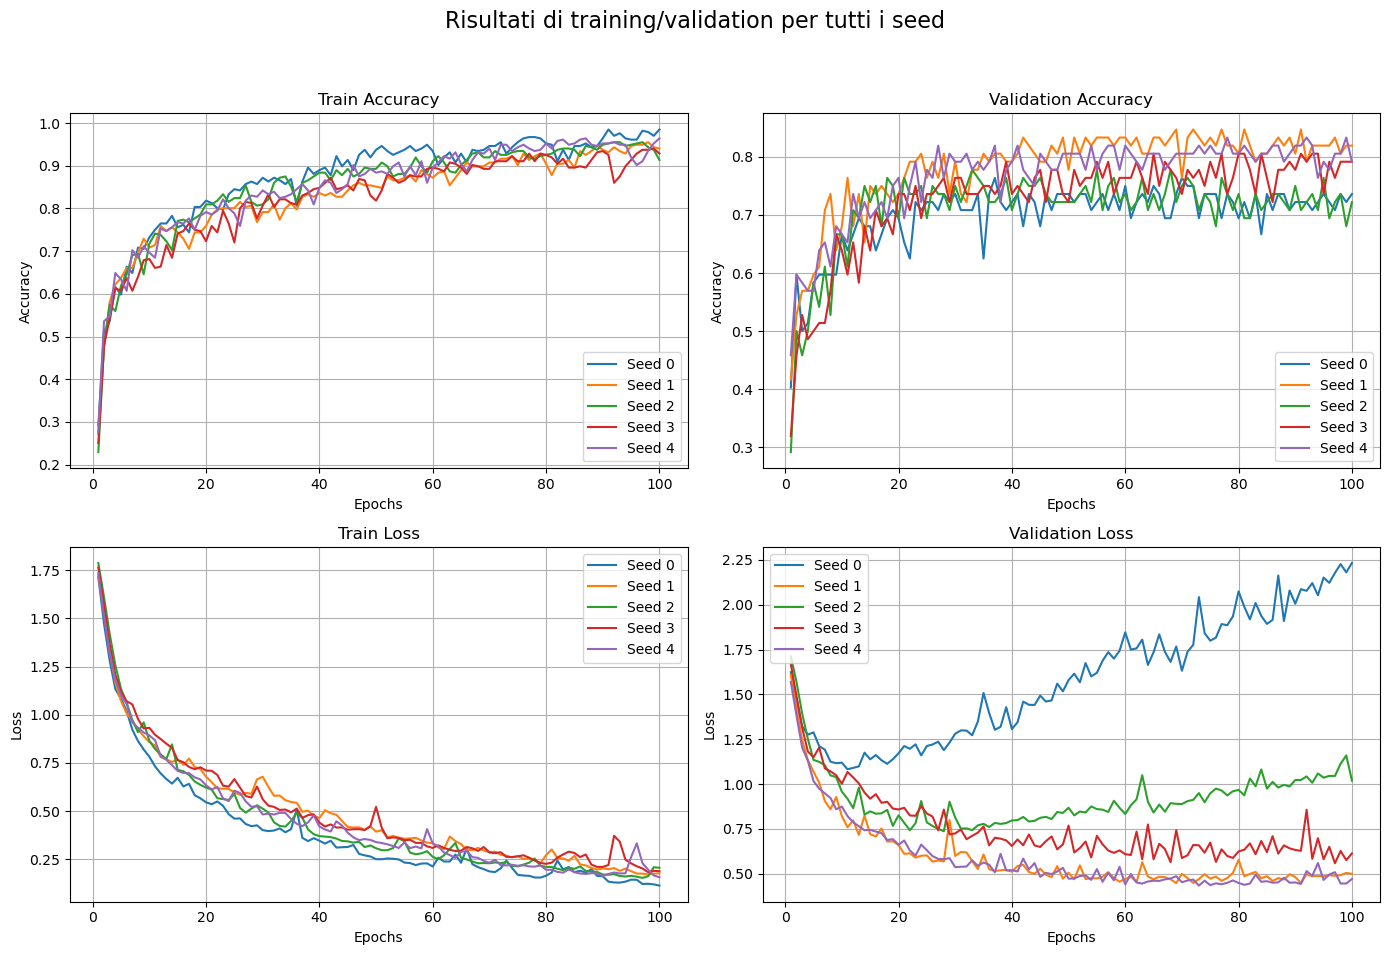

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Training/validation results for all seeds", fontsize=16)

for seed, metrics in results.items():
    epochs = range(1, len(metrics['train_acc']) + 1)
    
    # Train Accuracy
    axs[0, 0].plot(epochs, metrics['train_acc'], label=f'Seed {seed}')
    axs[0, 0].set_title('Train Accuracy')
    axs[0, 0].set_xlabel('Epochs')
    axs[0, 0].set_ylabel('Accuracy')
    
    # Validation Accuracy
    axs[0, 1].plot(epochs, metrics['val_acc'], label=f'Seed {seed}')
    axs[0, 1].set_title('Validation Accuracy')
    axs[0, 1].set_xlabel('Epochs')
    axs[0, 1].set_ylabel('Accuracy')
    
    # Train Loss
    axs[1, 0].plot(epochs, metrics['train_loss'], label=f'Seed {seed}')
    axs[1, 0].set_title('Train Loss')
    axs[1, 0].set_xlabel('Epochs')
    axs[1, 0].set_ylabel('Loss')
    
    # Validation Loss
    axs[1, 1].plot(epochs, metrics['val_loss'], label=f'Seed {seed}')
    axs[1, 1].set_title('Validation Loss')
    axs[1, 1].set_xlabel('Epochs')
    axs[1, 1].set_ylabel('Loss')

for ax in axs.flat:
    ax.legend()
    ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# 🔹 Best Seed and Model Selection

- Retrieve the list of seeds and their corresponding test accuracies.
- Determine which seed achieved the highest test accuracy.
- Extract the best model along with its preprocessing parameters (mean, standard deviation, maximum sequence length, number of features) and the associated LabelEncoder for future use.


In [8]:
seeds_list = list(results.keys())
test_accs = [results[s]['test_acc'] for s in seeds_list]

best_seed = max(results, key=lambda k: results[k]['test_acc'])
print(f"Best seed: {best_seed} with Test Accuracy: {results[best_seed]['test_acc']:.4f}")

best_model = all_models[best_seed]
best_mean, best_std, best_max_len, best_n_features = all_params[best_seed]
best_label_encoder = all_label_encoders[best_seed]

Best seed: 1 with Test Accuracy: 0.8889


# 🔹 Saving the Best Model and Preprocessing Artifacts

- Save the best-performing model to an `.h5` file.
- Store preprocessing parameters (mean, standard deviation, maximum sequence length, number of features) in a `.npz` file.
- Serialize and save the LabelEncoder using `pickle` for future label decoding.


In [ ]:
best_model.save("../../Predicters/Contesto/data/best_model_razza.h5")

np.savez("../../Predicters/Contesto/data/best_preprocessing_params.npz",
         mean=best_mean,
         std=best_std,
         max_len=best_max_len,
         n_features=best_n_features)

import pickle
with open("../../Predicters/Contesto/data/best_label_encoder.pkl", "wb") as f:
    pickle.dump(best_label_encoder, f)
